In [127]:
import pyproj
pyproj.datadir.set_data_dir("/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v4/Compiler/gcccore/proj/9.2.0/share/proj")

/home/ezrah442/venv/lib/python3.11/site-packages/pyproj/datadir.py:38: UserWarning: pyproj unable to set PROJ database path.
  _set_context_data_dir()


In [128]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xarray as xr

from config_utils import load_config
from model import SimpleModel
from preprocessing import create_2024_preprocessor_no_downscaling
from utils import (
    SECONDS_PER_DAY,
    global_date_series,
    global_mean,
    input_vars_from_config,
    integrate_over_pressure_levels,
    nn_radiative_response,
    nn_radiative_response_cross,
    plot_global_field,
    plot_north_pole_field,
    setup_timeseries_plot,
    target_var_from_config,
    to_monthly,
    weighted_residuals_by_month,
    weighted_residuals_by_year_month,
    setup_north_pole_map,
    plot_colormesh_on_map,
    plot_contours_on_map
)


def load_model_and_preprocessor(config, checkpoint_path: Path):
    checkpoint_data = torch.load(
        checkpoint_path, map_location="cpu", weights_only=False
    )
    model_config = checkpoint_data.get("config", config)
    model = SimpleModel(model_config)
    model.load_state_dict(checkpoint_data["model_state_dict"])
    model.eval()

    preprocessor = create_2024_preprocessor_no_downscaling(
        input_vars=input_vars_from_config(config),
        target_var=target_var_from_config(config),
        ecod=config.preprocess.ecod,
    )
    preprocessor.load(model.config.preprocess.params_dir)

    return model, preprocessor

In [199]:
year, month = 2012, 9
start_date, end_date = '2007-01', '2016-12'
output_root = Path('closure_test_2')

ALBEDO_KERNEL_PATH = Path("data/ERA5_kernels/ERA5_kernel_alb_TOA.nc")
WATER_VAPOR_KERNEL_PATH = Path(
    "data/ERA5_kernels/layer_specified_ta_wv_kernel/ERA5_kernel_wv_sw_nodp_TOA.nc"
)
QT_PATH = Path("data/era5/era5_plev_qt_monthly_downscaled.nc")
MONTH_NAMES = [
    "Jan", "Feb", "Mar",
    "Apr", "May", "Jun",
    "Jul", "Aug", "Sep",
    "Oct", "Nov", "Dec",
]


config = load_config('configs/model/fal/sobolev_mar_june_sep_dec_2011_2014.yaml')
checkpoint_path = Path(config.train.checkpoint_dir) / "best_model.pt"
model, preprocessor = load_model_and_preprocessor(config, checkpoint_path)

K_a = xr.open_dataset(ALBEDO_KERNEL_PATH)
K_q = xr.open_dataset(WATER_VAPOR_KERNEL_PATH)
kernel_grid = {"latitude": K_a.latitude, "longitude": K_a.longitude}

NORTH_BOUNDARY = 75
NORTH_MASK = K_a.latitude.values > NORTH_BOUNDARY

data_path = Path('data/era5')
ds = xr.open_mfdataset(list(data_path.glob("era5_single_levels_monthly_*.nc")))
ds = ds.sel(date=slice(start_date, end_date)).interp(**kernel_grid)
ds["tsr"] = ds.tsr / SECONDS_PER_DAY

ds_monthly = to_monthly(ds.copy(deep=True))
ds_monthly_means = ds_monthly.mean("year")
anomaly = ds_monthly - ds_monthly_means
anomaly = anomaly.compute()


ecod_anomaly = preprocessor.transform(ds_monthly.sel(year=year, month=month)).ecod - preprocessor.transform((ds_monthly + anomaly).sel(year=year, month=month)).ecod

cloud_vars = ["tcc", "hcc", "mcc", "lcc", "tciw", "tclw"]
ds_monthly_clr = ds_monthly.assign(
    {v: xr.zeros_like(ds_monthly[v]) for v in cloud_vars}
)

ds_tsrc = xr.open_mfdataset(list(data_path.glob("era5_tsrc_monthly_*.nc")))
ds_tsrc = ds_tsrc.sel(date=slice(start_date, end_date)).tsrc
ds_tsrc = ds_tsrc.interp(**kernel_grid).compute() / SECONDS_PER_DAY
ds_tsrc_monthly = to_monthly(ds_tsrc.copy(deep=True))
dR_clr = ds_tsrc_monthly - ds_tsrc_monthly.mean("year")
dR = anomaly.tsr.interp(**kernel_grid).compute()

response_save_path = 'closure_test_2/saved_responses_closure_test_2.nc'
responses = xr.load_dataset(response_save_path)

Calculating ECOD...
Calculating ECOD...


In [130]:
response = responses.sel(year=year, month=month).dR_a_nn_all[NORTH_MASK]
alb_change = anomaly.sel(year=year, month=month).fal[NORTH_MASK]

In [155]:
print(responses.data_vars)

Data variables:
    dR_era5_all   (latitude, longitude, year, month) float64 10MB 1.725e-14 ....
    dR_era5_clr   (latitude, longitude, year, month) float64 10MB 1.294e-14 ....
    dR_a_nn_all   (year, month, latitude, longitude) float64 10MB -0.006788 ....
    dR_c_nn_all   (year, month, latitude, longitude) float64 10MB 0.6782 ... ...
    dR_q_nn_all   (year, month, latitude, longitude) float64 10MB -0.041 ... ...
    dR_a_nn_clr   (year, month, latitude, longitude) float64 10MB -0.01074 .....
    dR_q_nn_clr   (year, month, latitude, longitude) float64 10MB -0.3746 ......
    dR_a_k_all    (month, latitude, longitude, year) float64 10MB 0.0 ... -0....
    dR_c_k_all    (latitude, longitude, year, month) float64 10MB 4.312e-15 ....
    dR_q_k_all    (month, latitude, longitude, year) float64 10MB 0.0 ... 0.8703
    dR_a_k_clr    (month, latitude, longitude, year) float64 10MB 0.0 ... -0....
    dR_q_k_clr    (month, latitude, longitude, year) float64 10MB 0.0 ... 0.9987
    dR_aq_nn

/lustre09/project/6003571/ezrah442/solobev-learning/utils.py:81: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  return m.pcolormesh(x, y, data_sub, shading="nearest", cmap=cmap, vmin=vmin, vmax=vmax)
/lustre09/project/6003571/ezrah442/solobev-learning/utils.py:81: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  return m.pcolormesh(x, y, data_sub, shading="nearest", cmap=cmap, vmin=vmin, vmax=vmax)
/lustre09/project/6003571/ezrah442/solobev-learning/utils.py:81: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or dec

Text(0.5, 1.0, '$\\Delta R^{K}_a$')

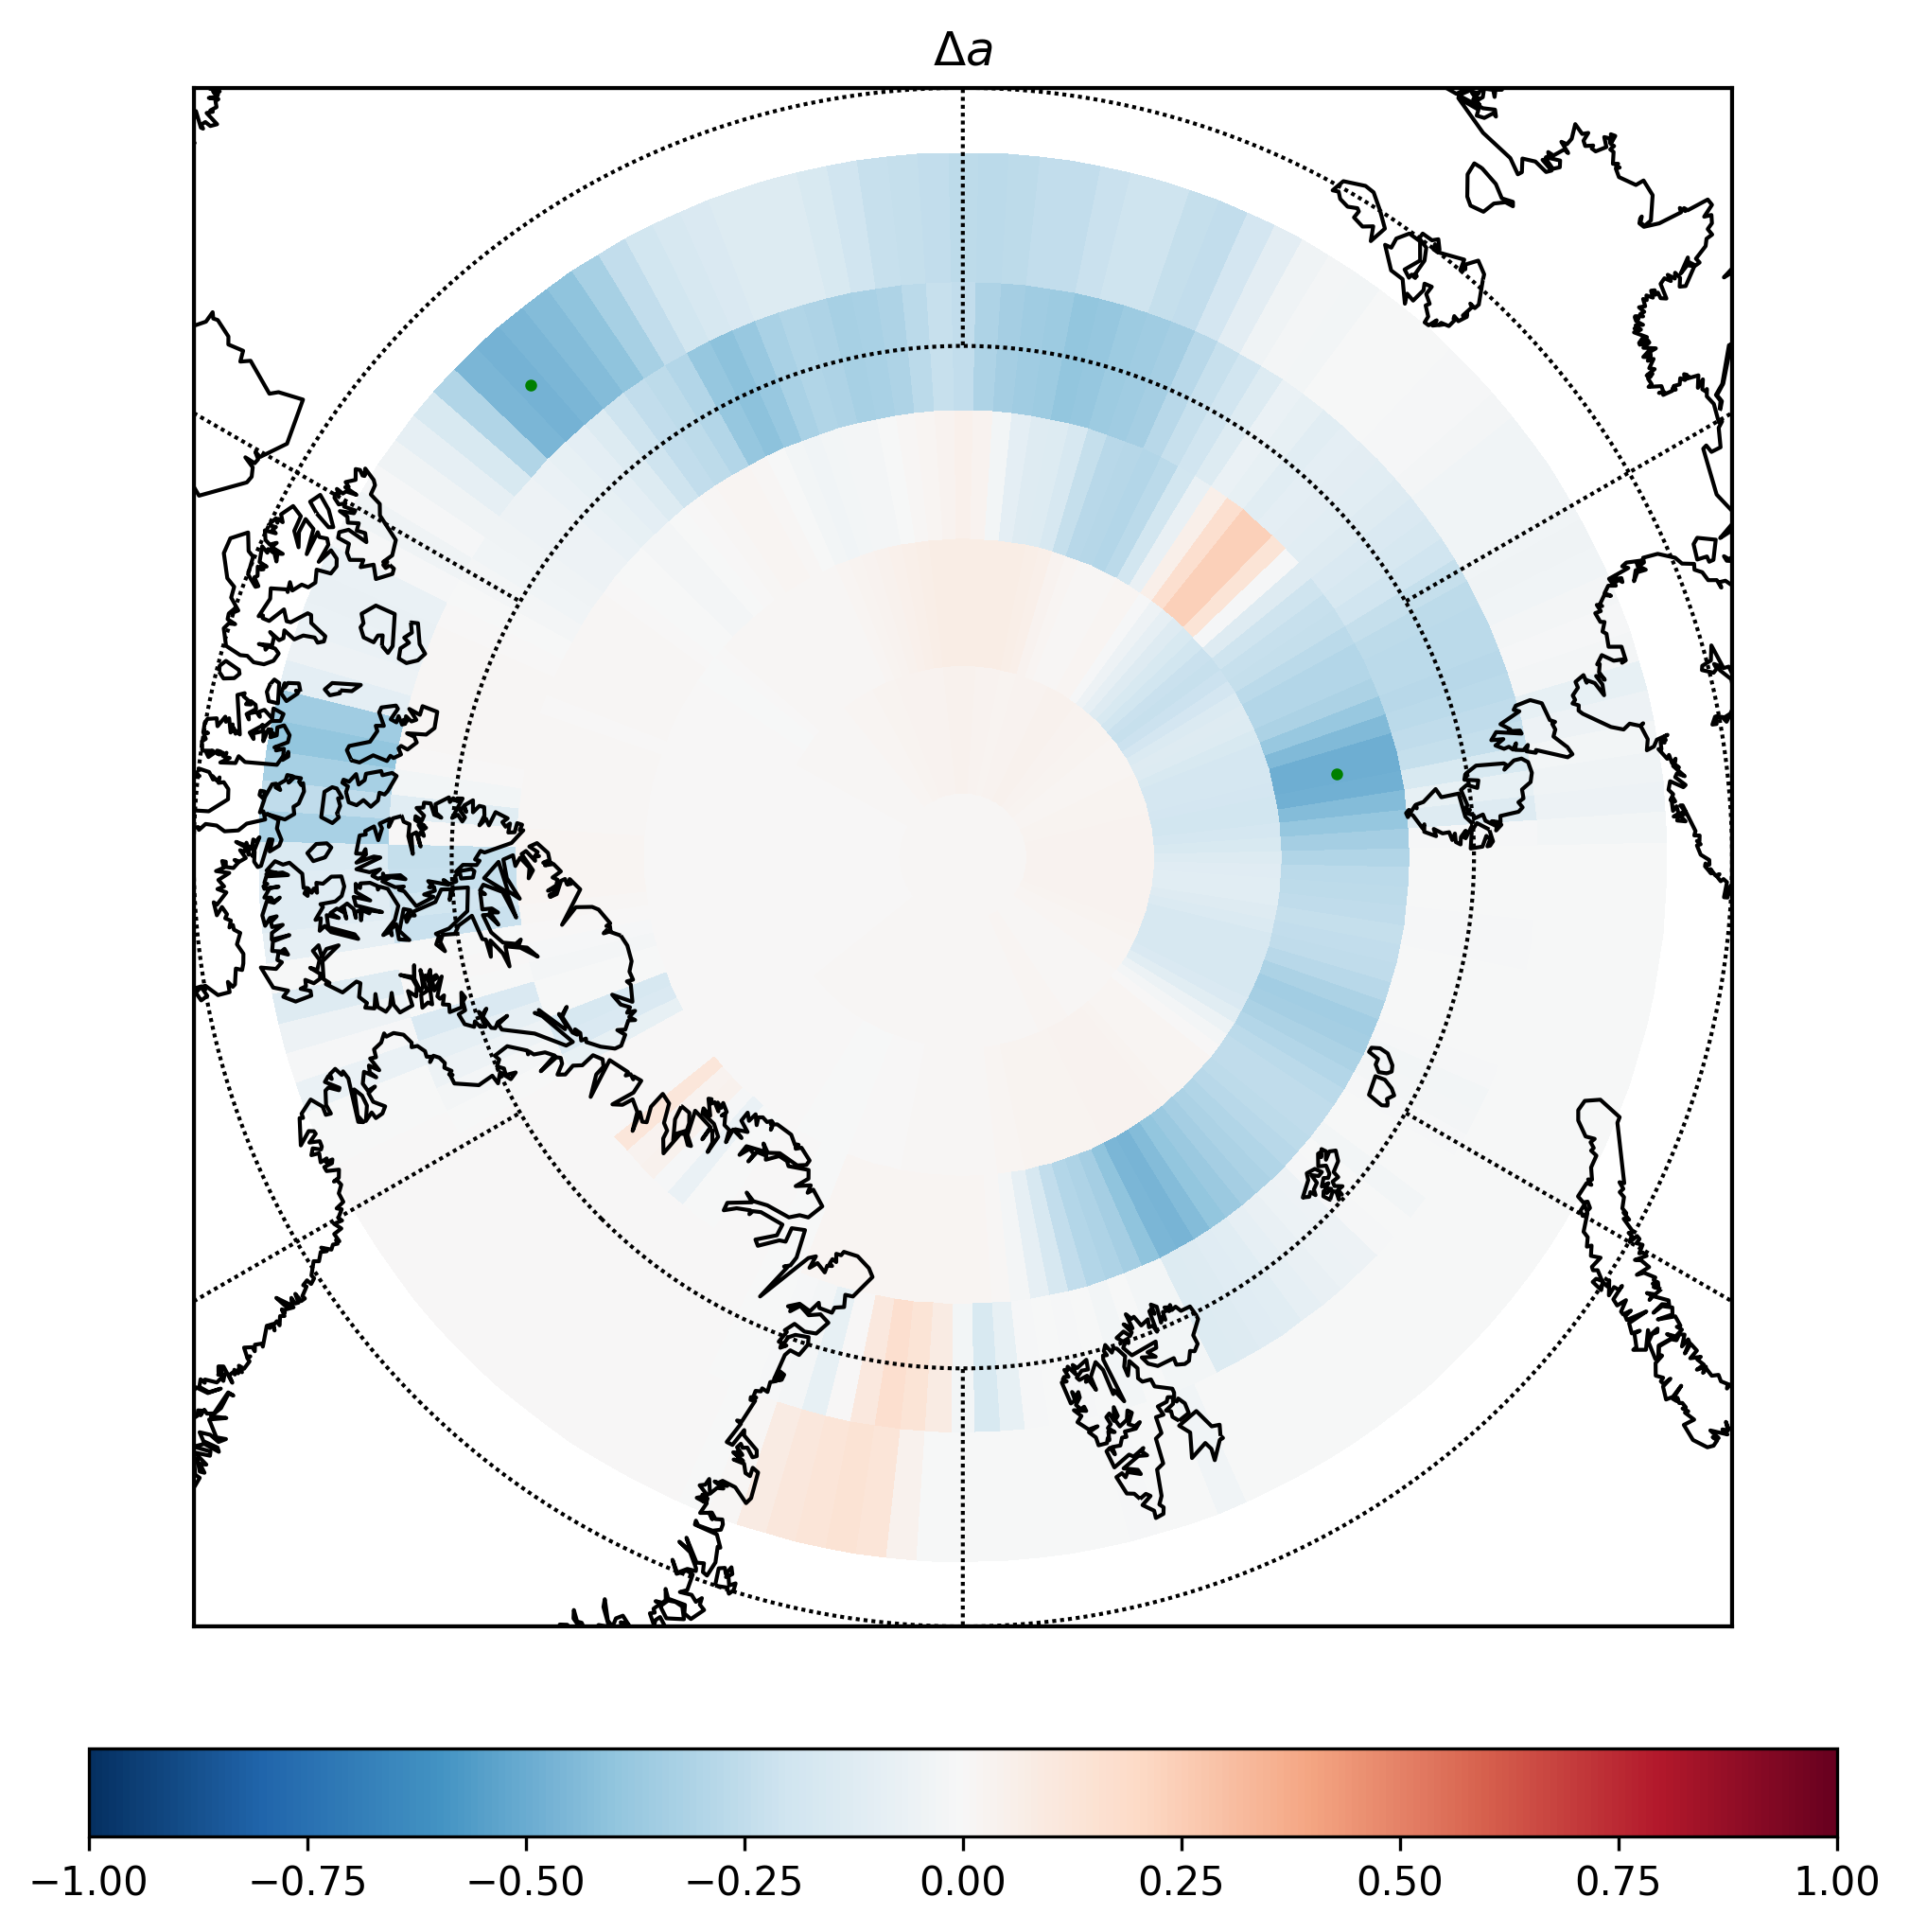

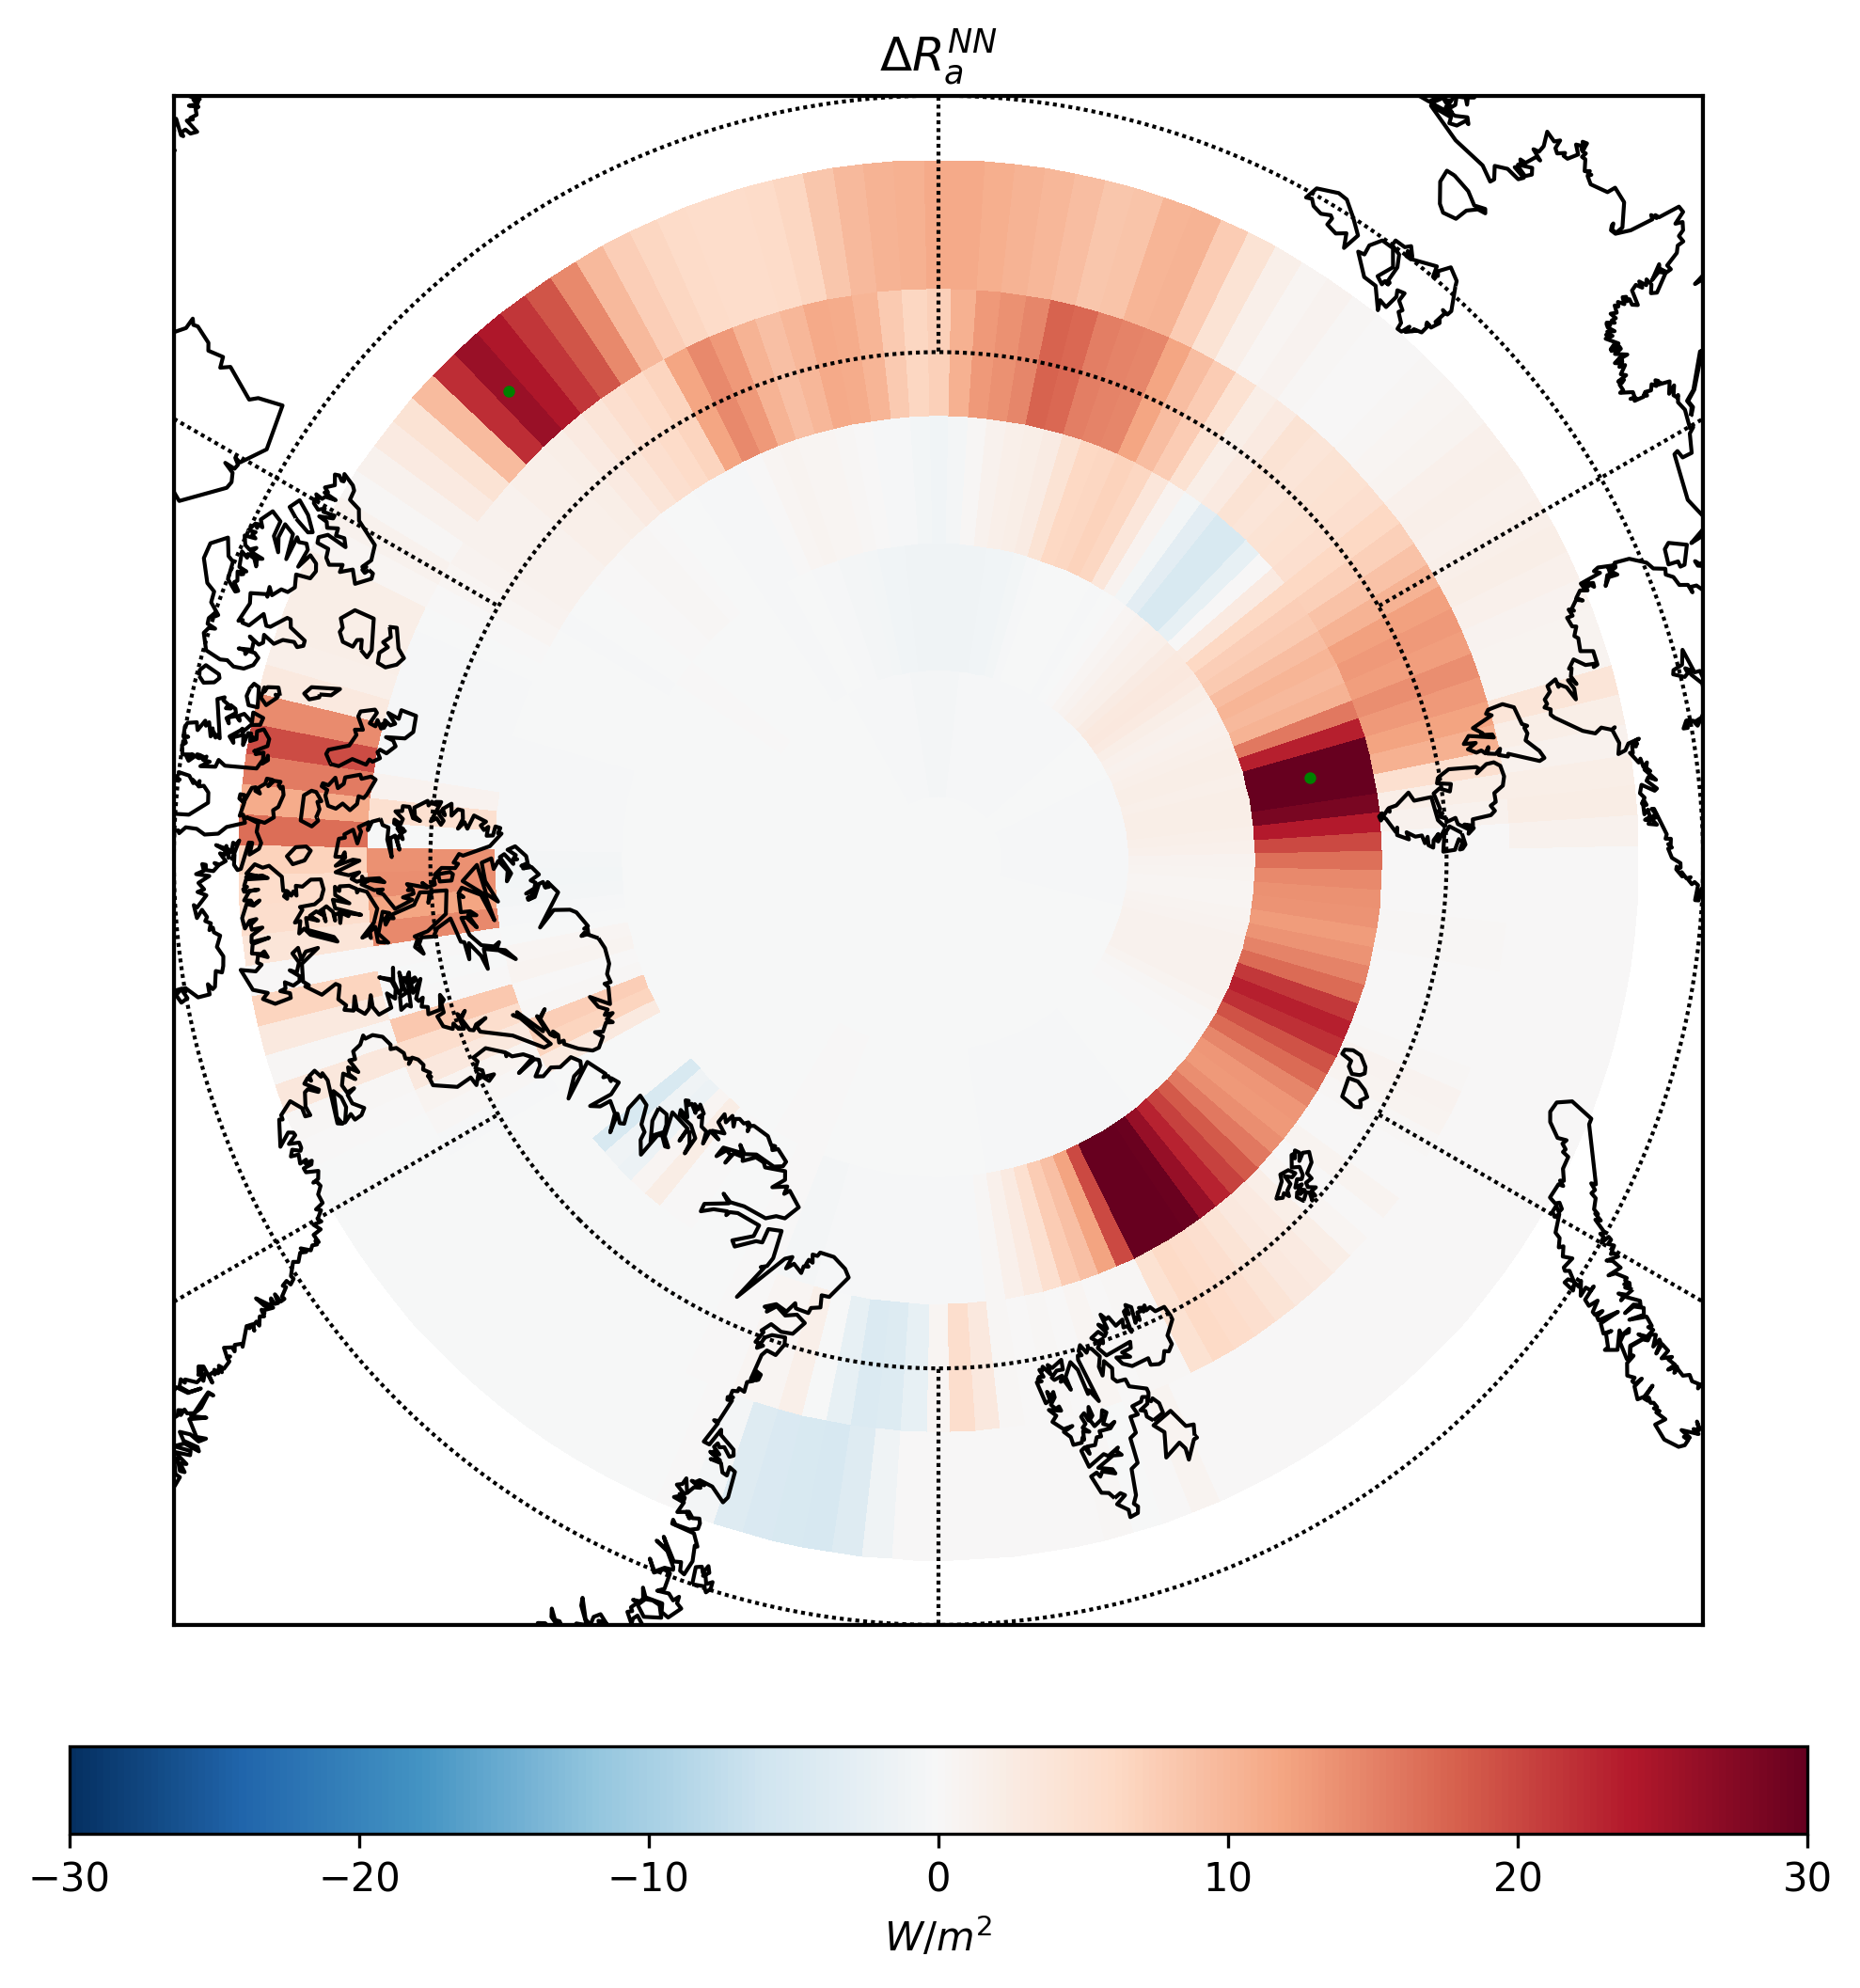

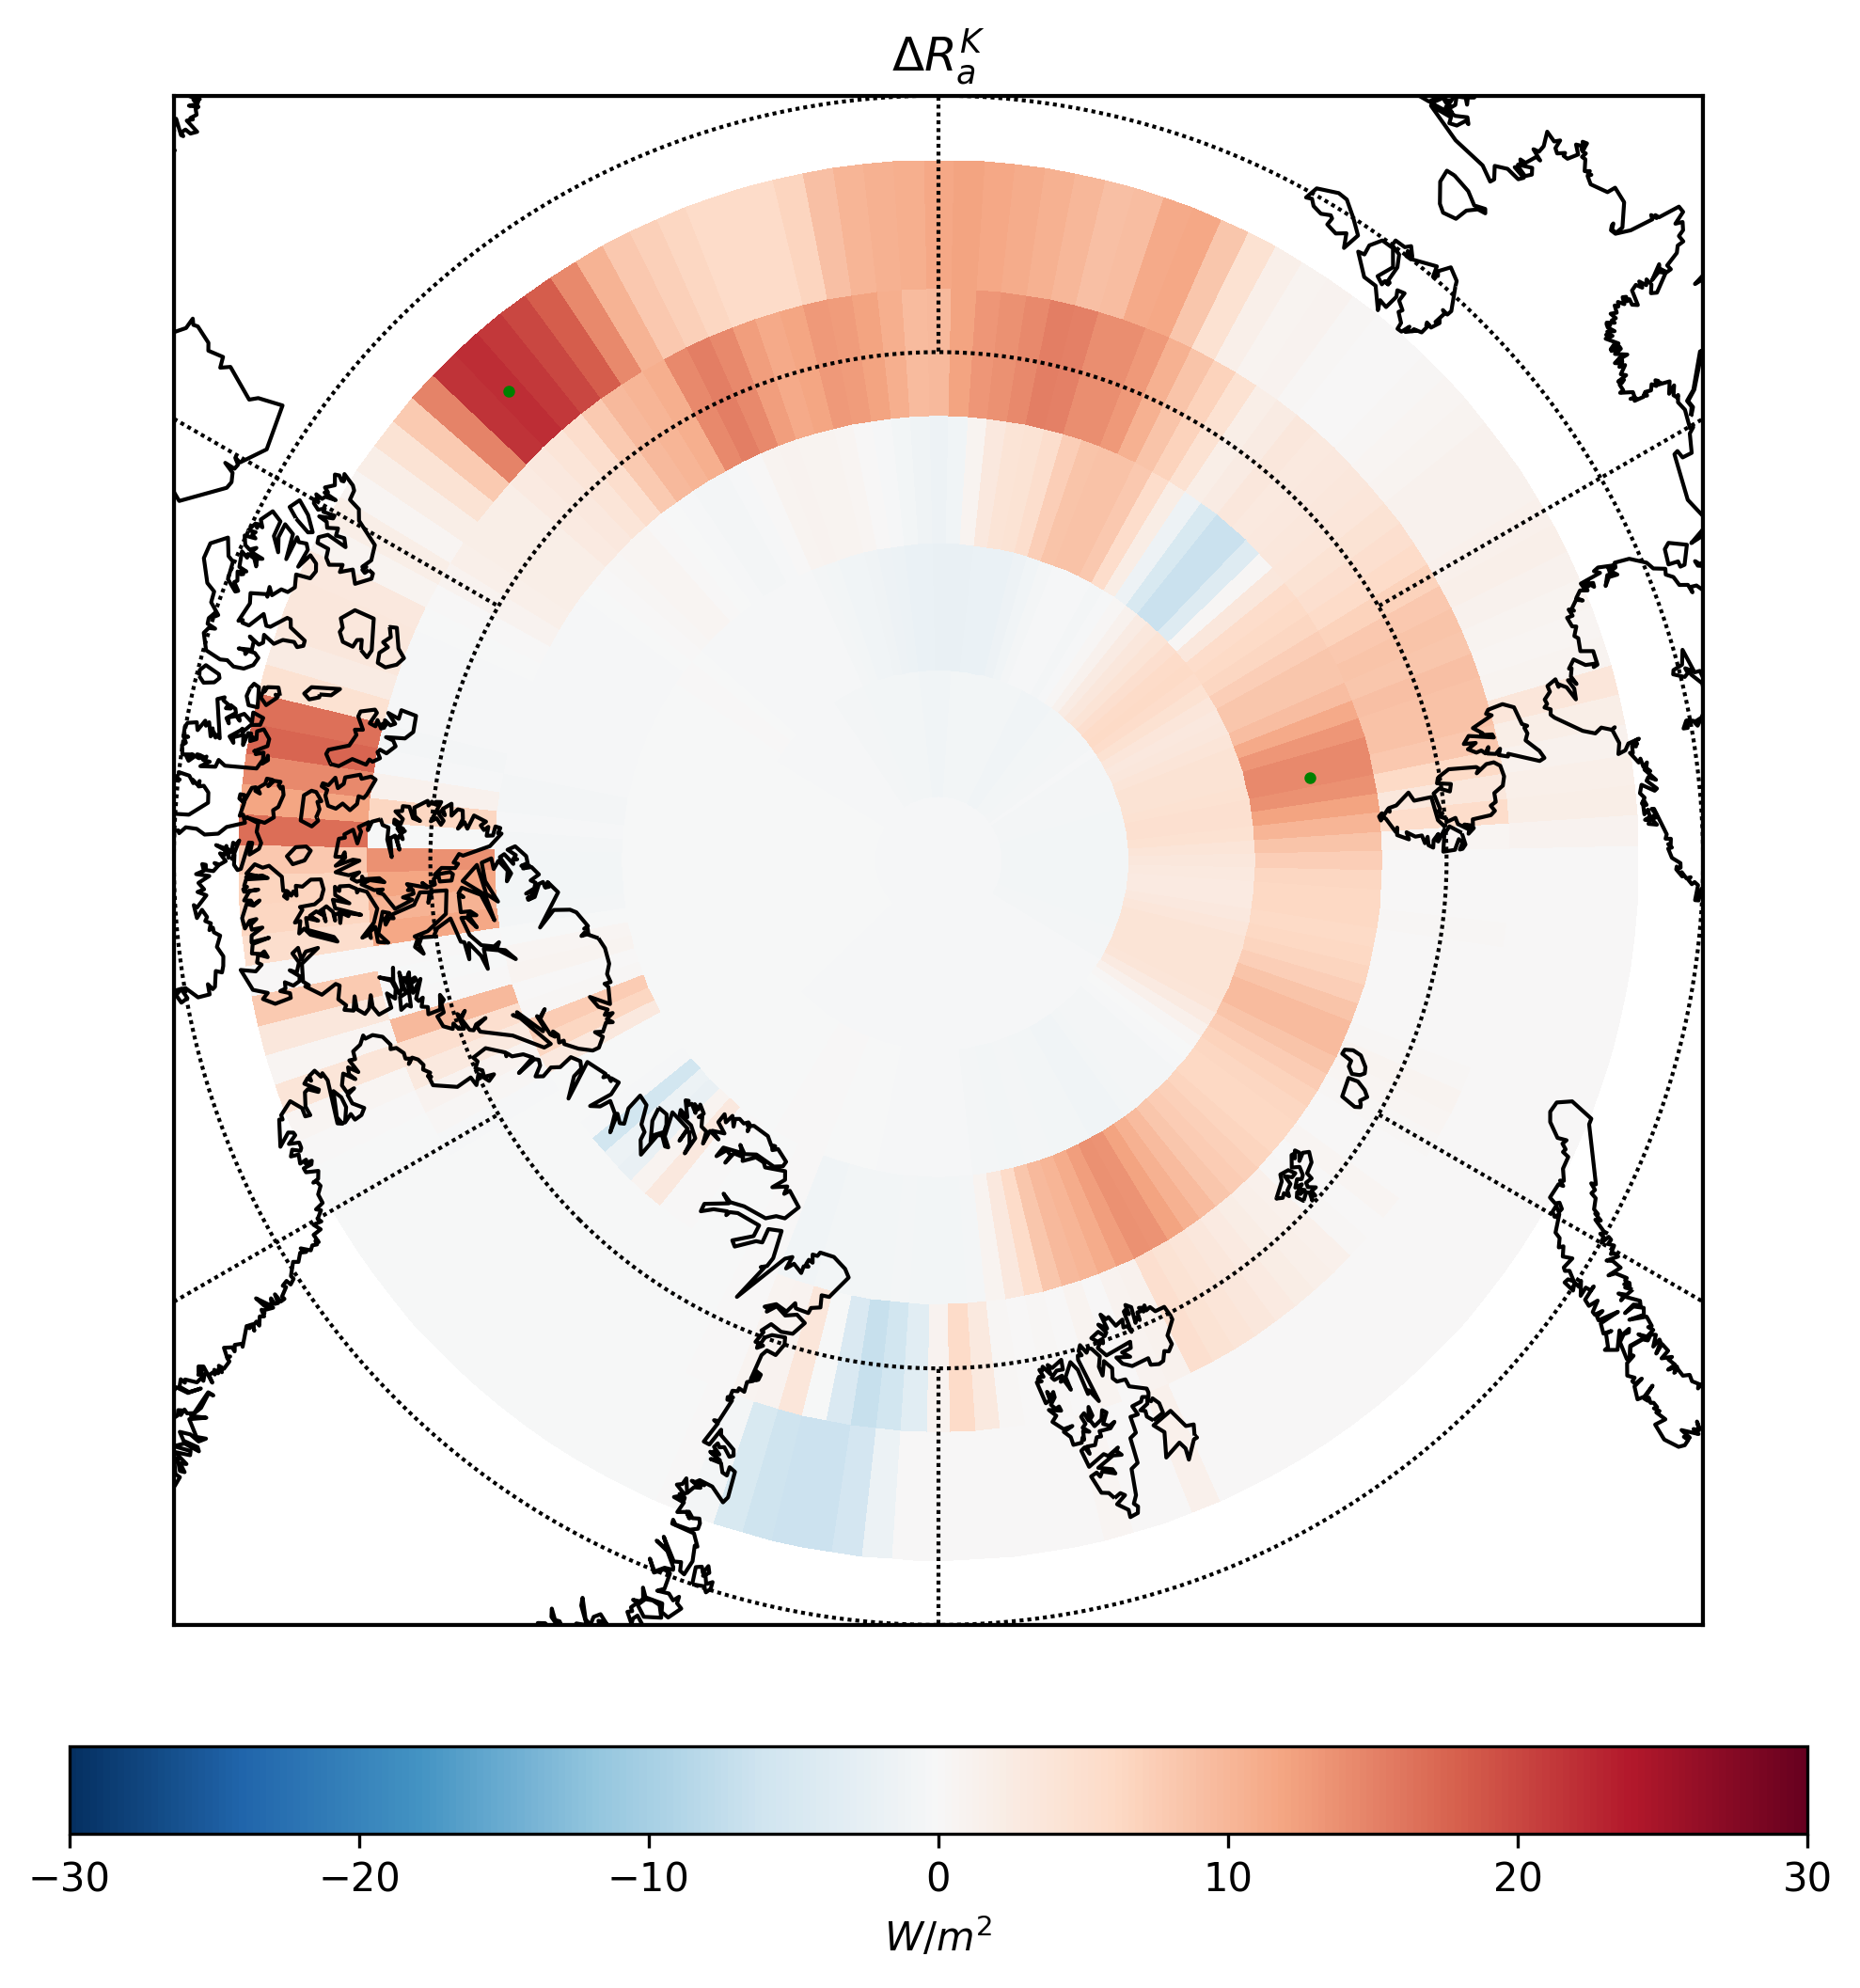

In [176]:
lat = response.latitude
lon = response.longitude
vmin = -1
vmax = 1
field = alb_change
cmap = 'RdBu_r'

# albedo plot
fig = plt.figure(figsize=(8, 8), dpi=300)
m = setup_north_pole_map(boundary=75)
artist = plot_colormesh_on_map(m, lon, lat, field, cmap=cmap, vmin=vmin, vmax=vmax)

x1, y1= [222.5, 77.5]
x2, y2 = [102.5, 82.5]
x, y = m([x1, x2], [y1, y2])
m.scatter(x, y, s=4, color='green')
plt.colorbar(artist, orientation="horizontal", fraction=0.05, pad=0.07, label='')
plt.title('$\Delta a$')


vmin = -30
vmax = 30
field = response
cmap = 'RdBu_r'
fig = plt.figure(figsize=(8, 8), dpi=300)
m = setup_north_pole_map(boundary=75)
artist = plot_colormesh_on_map(m, lon, lat, field, cmap=cmap, vmin=vmin, vmax=vmax)

m.scatter(x, y, s=4, color='green')
plt.colorbar(artist, orientation="horizontal", fraction=0.05, pad=0.07, label='$W/m^2$')
plt.title('$\Delta R^{NN}_a$')


vmin = -30
vmax = 30
field = responses.sel(year=2012, month=9)['dR_a_k_all']
cmap = 'RdBu_r'
fig = plt.figure(figsize=(8, 8), dpi=300)
m = setup_north_pole_map(boundary=75)
artist = plot_colormesh_on_map(m, lon, lat, field, cmap=cmap, vmin=vmin, vmax=vmax)

m.scatter(x, y, s=4, color='green')
plt.colorbar(artist, orientation="horizontal", fraction=0.05, pad=0.07, label='$W/m^2$')
plt.title('$\Delta R^{K}_a$')

In [393]:
anomaly['ecod'] = ecod_anomaly
pos_anomaly = xr.concat([
    anomaly.sel(year=year, month=month, longitude=x1, latitude=y1, method='nearest'),
    anomaly.sel(year=year, month=month, longitude=x2, latitude=y2, method='nearest')
], 'pos').compute()

pos_data = xr.concat([
    ds_monthly.sel(year=year, month=month, longitude=x1, latitude=y1, method='nearest'),
    ds_monthly.sel(year=year, month=month, longitude=x2, latitude=y2, method='nearest')
], 'pos').compute()
pos_data['ecod'] = compute_cloud_optical_depth(pos_data.tclw, pos_data.tciw, pos_data.tcc)

pos_response = xr.concat([
    responses.sel(year=year, month=month, longitude=x1, latitude=y1, method='nearest'),
    responses.sel(year=year, month=month, longitude=x2, latitude=y2, method='nearest')
], 'pos').compute()

In [394]:
print(pos_response[['dR_era5_all', 'dR_a_nn_all', 'dR_c_nn_all', 'dR_q_nn_all',  'dR_a_k_all', 'dR_c_k_all', 'dR_q_k_all']])
print(pos_data.as_numpy()[['fal', 'tcc', 'hcc', 'mcc', 'lcc', 'tciw', 'tclw', 'tcwv', 'tisr', 'tsr', 'ecod']])
print(pos_anomaly.as_numpy()[['fal', 'tcc', 'hcc', 'mcc', 'lcc', 'tciw', 'tclw', 'tcwv', 'tisr', 'tsr', 'ecod']])

<xarray.Dataset> Size: 144B
Dimensions:      (pos: 2)
Coordinates:
    latitude     (pos) float32 8B 77.5 82.5
    longitude    (pos) float32 8B 222.5 102.5
    year         int64 8B 2012
    month        int64 8B 9
Dimensions without coordinates: pos
Data variables:
    dR_era5_all  (pos) float64 16B 15.5 6.294
    dR_a_nn_all  (pos) float64 16B 25.93 32.46
    dR_c_nn_all  (pos) float64 16B -0.002607 -0.7132
    dR_q_nn_all  (pos) float64 16B -0.4608 -0.07626
    dR_a_k_all   (pos) float64 16B 22.07 14.5
    dR_c_k_all   (pos) float64 16B 2.79 1.212
    dR_q_k_all   (pos) float64 16B 0.5215 0.09566
<xarray.Dataset> Size: 208B
Dimensions:    (pos: 2)
Coordinates:
    latitude   (pos) float32 8B 77.5 82.5
    longitude  (pos) float32 8B 222.5 102.5
    year       int64 8B 2012
    month      int64 8B 9
Dimensions without coordinates: pos
Data variables:
    fal        (pos) float64 16B 0.07001 0.07564
    tcc        (pos) float64 16B 0.9441 0.979
    hcc        (pos) float64 16B 0.2877

In [283]:
def tsr_tisr_fal_contour_test(
    processed_ds: xr.Dataset,
    preprocessor,
    model,
    config,
    figures_path: Path = Path("."),
    latitude=y1,
    longitude=x1,
    scatter=True,
    extrapolate=False,
    n_fal: int = 100,
    n_tisr: int = 100,
    da=None,
    dtisr=None,
):
    assert isinstance(preprocessor, SequentialPreprocessor)
    scaler = preprocessor.preprocessors[-1]
    assert isinstance(scaler, XarrayMinMaxScaler)
    if input_var_from_config(config) != "fal":
        print("Skipping fal/tisr TSR contour; model input variable is not fal.")
        return

    ordered = ordered_dataset_for_config(processed_ds, config)
    target = target_var_from_config(config)
    feature_names = [v for v in ordered.data_vars if v != target]
    required = {"fal", "tisr"}
    missing = required.difference(feature_names)
    if missing:
        print(f"Skipping fal/tisr TSR contour; missing features: {sorted(missing)}")
        return

    observed_vars = ["fal", "tisr"]
    if "ecod" in feature_names:
        observed_vars.append("ecod")
    observed = scaler.inverse_transform(ordered[observed_vars])
    base_point = ordered.sel(latitude=latitude, longitude=longitude)
    observed_base_point = observed.sel(latitude=latitude, longitude=longitude)
    base_features = np.array(
        [float(base_point[name]) for name in feature_names],
        dtype=np.float32,
    )

    fal_values = np.linspace(
        float(scaler.data_min_["fal"]),
        float(scaler.data_max_["fal"]),
        n_fal,
    )
    tisr_values = np.linspace(
        float(scaler.data_min_["tisr"]),
        float(scaler.data_max_["tisr"]),
        n_tisr,
    )
    if extrapolate:
        fal_values = np.linspace(0, float(scaler.data_max_["fal"]) * 2, n_fal)
        tisr_values = np.linspace(0, float(scaler.data_max_["tisr"]) * 2, n_tisr)
    fal_grid, tisr_grid = np.meshgrid(fal_values, tisr_values)

    inputs_np = np.broadcast_to(
        base_features, (n_tisr * n_fal, len(feature_names))
    ).copy()
    inputs_np[:, feature_names.index("fal")] = scale_minmax_value(
        scaler, "fal", fal_grid.ravel()
    )
    inputs_np[:, feature_names.index("tisr")] = scale_minmax_value(
        scaler, "tisr", tisr_grid.ravel()
    )
    if "ecod_fal" in feature_names and "ecod" in observed_base_point:
        inputs_np[:, feature_names.index("ecod_fal")] = scale_minmax_value(
            scaler,
            "ecod_fal",
            (float(observed_base_point["ecod"]) * fal_grid).ravel(),
        )

    with torch.no_grad():
        outputs = (
            model(torch.from_numpy(inputs_np).float())
            .cpu()
            .numpy()
            .reshape(n_tisr, n_fal)
        )

    target_min = float(scaler.data_min_[target])
    target_range = float(scaler.data_max_[target] - scaler.data_min_[target])
    target_scaled = (outputs - scaler.min_val) / (scaler.max_val - scaler.min_val)
    target_values = (target_scaled * target_range + target_min) / SECONDS_PER_DAY

    fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
    contour = ax.contourf(
        fal_grid,
        tisr_grid,
        target_values,
        levels=31,
        cmap="Spectral",
    )
    #contour = ax.pcolormesh(
    #    fal_grid,
    #    tisr_grid,
    #    target_values,
    #)
    if scatter:
        ax.scatter(
            observed["fal"].to_numpy().ravel(),
            observed["tisr"].to_numpy().ravel(),
            s=1,
            c="black",
            alpha=0.05,
            linewidths=0,
            label="dataset",
        )
        ax.legend(loc="upper right", markerscale=4)
    ax.scatter(
        [float(observed_base_point["fal"])],
        [float(observed_base_point["tisr"])],
        s=20,
        c="white",
        edgecolors="black",
        label='September Mean'
    )
    ax.scatter(
        [float(observed_base_point["fal"]+da)],
        [float(observed_base_point["tisr"]+dtisr)],
        s=20,
        c="white",
        edgecolors="black",
        label='September 2012',
        marker='*'
    )
    ax.set_xlabel("fal")
    ax.set_ylabel("tisr")
    ax.set_title(
        f"NN {target.upper()} over fal/tisr; "
        f"lat={latitude:.2f}, lon={longitude:.2f}"
    )
    cb = fig.colorbar(contour, ax=ax)
    cb.set_label("$W/m^2$")
    fig.tight_layout()
    ax.legend()
    fig.savefig(figures_path / f"{latitude}_{longitude}_contour_fal_tisr.png")
    plt.close(fig)


In [269]:
# --- setup output directory ---
from utils import make_kernel_filename,make_era5_filename, input_var_from_config, ordered_dataset_for_config, scale_minmax_value
from preprocessing import create_2024_preprocessor, SequentialPreprocessor, XarrayMinMaxScaler

output_dir = Path('scratch')
if not output_dir.exists():
    output_dir.mkdir(parents=True, exist_ok=True)

processed_dataset = preprocessor.transform(ds_monthly_means.sel(month=9).compute())

Calculating ECOD...


In [284]:
d1 = pos_anomaly.sel(pos=0)
d2 = pos_anomaly.sel(pos=1)

tsr_tisr_fal_contour_test(processed_dataset, preprocessor, model, config, scatter=False, figures_path=output_dir, latitude=y1, longitude=x1, da=d1.fal, dtisr=d1.tisr)
tsr_tisr_fal_contour_test(processed_dataset, preprocessor, model, config, scatter=False, figures_path=output_dir, latitude=y2, longitude=x2, da=d2.fal, dtisr=d2.tisr)

In [414]:
s1 = pos_data - pos_anomaly
s2 = pos_data

In [417]:
print(s1[['fal', 'tcc', 'hcc','mcc','lcc','tciw','tclw','tcwv','ecod']])
print(s2)

<xarray.Dataset> Size: 176B
Dimensions:    (pos: 2)
Coordinates:
    latitude   (pos) float32 8B 77.5 82.5
    longitude  (pos) float32 8B 222.5 102.5
    year       int64 8B 2012
    month      int64 8B 9
Dimensions without coordinates: pos
Data variables:
    fal        (pos) float64 16B 0.545 0.5656
    tcc        (pos) float64 16B 0.9593 0.966
    hcc        (pos) float64 16B 0.3177 0.3343
    mcc        (pos) float64 16B 0.4327 0.4849
    lcc        (pos) float64 16B 0.905 0.9153
    tciw       (pos) float64 16B 0.02131 0.02424
    tclw       (pos) float64 16B 0.06277 0.07772
    tcwv       (pos) float64 16B 7.668 8.757
    ecod       (pos) float64 16B 10.94 14.88
Attributes:
    Conventions:  CF-1.6
    history:      2026-06-16 17:52:10 GMT by grib_to_netcdf-2.31.0: grib_to_n...
<xarray.Dataset> Size: 288B
Dimensions:    (pos: 2)
Coordinates:
    latitude   (pos) float32 8B 77.5 82.5
    longitude  (pos) float32 8B 222.5 102.5
    year       int64 8B 2012
    month      int64 8B 

In [397]:
scaler = preprocessor.preprocessors[-1]

In [398]:
s1p = preprocessor.transform(s1)
s2p = preprocessor.transform(s2)

def prepare(ds):
    return torch.from_numpy(ds.to_dataarray().transpose('pos', 'variable')[..., :11].values).to(torch.float32)

baseline = prepare(s1p)
input_tensor = prepare(s2p)

Calculating ECOD...
Calculating ECOD...


In [410]:
print(model(input_tensor))

tensor([-0.7203, -0.8081], grad_fn=<SqueezeBackward1>)


In [336]:
from captum.attr import IntegratedGradients

In [337]:
ig = IntegratedGradients(model)

In [400]:
input_tensor.requires_grad_()
attr, delta = ig.attribute(input_tensor, baselines=baseline, return_convergence_delta=True)
attr = attr.detach().numpy()

In [401]:
print(attr, delta)

[[ 7.47369379e-02  9.19531041e-04  6.55152544e-04  1.26799557e-03
  -4.61876189e-04  2.19935896e-06  3.69184394e-03 -1.92441721e-03
  -3.99253704e-03 -6.45448267e-03 -1.31912027e-02]
 [ 4.67230417e-02 -1.82354217e-03 -1.03437703e-03  2.27019144e-03
   1.61551419e-04 -1.97333109e-04  1.29039455e-02 -5.27067226e-04
  -4.08792635e-03 -1.88606642e-02 -6.36569643e-03]] tensor([-7.0781e-08, -2.2352e-07])


In [402]:
target = target_var_from_config(config)
target_scale = float(scaler.data_max_[target] - scaler.data_min_[target])
attrs_wm2 = attr * target_scale / SECONDS_PER_DAY

In [403]:
print(attrs_wm2.sum(1))

[25.168474 13.284662]


In [404]:
print(pos_anomaly.data_vars)

Data variables:
    skt      (pos) float64 16B 3.013 2.471
    fal      (pos) float64 16B -0.475 -0.49
    tcc      (pos) float64 16B -0.01527 0.01299
    hcc      (pos) float64 16B -0.02997 0.07345
    mcc      (pos) float64 16B 0.075 -0.06114
    lcc      (pos) float64 16B -0.0123 -0.0228
    sp       (pos) float64 16B -543.9 171.1
    tciw     (pos) float64 16B 0.001185 -0.004774
    tclw     (pos) float64 16B 0.0062 0.01612
    tco3     (pos) float64 16B 2.586e-05 -0.0001669
    tcwv     (pos) float64 16B 1.193 0.5243
    tisr     (pos) float64 16B -1.584e+05 -1.803e+05
    tsr      (pos) float64 16B 15.5 6.294
    ttr      (pos) float64 16B -3.063e+05 -2.212e+05
    ecod     (pos) float64 16B -0.01926 -0.06024


In [405]:
attr_ds = xr.Dataset()

In [406]:
for i in range(11):
    name = list(s1p.data_vars)[i]
    attr_ds[name] = attrs_wm2[:, i]

In [411]:
print(attr_ds)

<xarray.Dataset> Size: 88B
Dimensions:   (fal: 2, hcc: 2, mcc: 2, lcc: 2, sp: 2, tciw: 2, tclw: 2,
               tcwv: 2, tisr: 2, ecod: 2, ecod_fal: 2)
Coordinates:
  * fal       (fal) float32 8B 34.05 21.28
  * hcc       (hcc) float32 8B 0.4189 -0.8307
  * mcc       (mcc) float32 8B 0.2985 -0.4712
  * lcc       (lcc) float32 8B 0.5776 1.034
  * sp        (sp) float32 8B -0.2104 0.07359
  * tciw      (tciw) float32 8B 0.001002 -0.08989
  * tclw      (tclw) float32 8B 1.682 5.878
  * tcwv      (tcwv) float32 8B -0.8767 -0.2401
  * tisr      (tisr) float32 8B -1.819 -1.862
  * ecod      (ecod) float32 8B -2.94 -8.592
  * ecod_fal  (ecod_fal) float32 8B -6.009 -2.9
Data variables:
    *empty*


In [8]:
import xarray as xr

In [21]:
feedbacks = xr.open_dataset('closure_test_2/feedbacks.nc')
print(feedbacks)

<xarray.Dataset> Size: 856B
Dimensions:                            (degree: 2, cov_i: 2, cov_j: 2)
Coordinates:
  * degree                             (degree) int64 16B 1 0
Dimensions without coordinates: cov_i, cov_j
Data variables: (12/45)
    dR_era5_all_polyfit_coefficients   (degree) float64 16B ...
    dR_era5_all_polyfit_residuals      float64 8B ...
    dR_era5_all_polyfit_covariance     (cov_i, cov_j) float64 32B ...
    dR_era5_clr_polyfit_coefficients   (degree) float64 16B ...
    dR_era5_clr_polyfit_residuals      float64 8B ...
    dR_era5_clr_polyfit_covariance     (cov_i, cov_j) float64 32B ...
    ...                                 ...
    dR_ac_nn_all_polyfit_coefficients  (degree) float64 16B ...
    dR_ac_nn_all_polyfit_residuals     float64 8B ...
    dR_ac_nn_all_polyfit_covariance    (cov_i, cov_j) float64 32B ...
    dR_qc_nn_all_polyfit_coefficients  (degree) float64 16B ...
    dR_qc_nn_all_polyfit_residuals     float64 8B ...
    dR_qc_nn_all_polyfit_covari

In [19]:
regression_vars = ['dR_a_k_all', 'dR_c_k_all', 'dR_q_k_all'] + ['dR_a_k_clr', 'dR_q_k_clr'] + ['dR_a_nn_all', 'dR_c_nn_all', 'dR_q_nn_all'] + ['dR_a_nn_clr', 'dR_q_nn_clr'] + ['dR_era5_all', 'dR_era5_clr']

print(feedbacks[[f"{var}_polyfit_covariance" for var in regression_vars]].as_numpy().sel(cov_i=0, cov_j=0))

<xarray.Dataset> Size: 96B
Dimensions:                         ()
Data variables:
    dR_a_k_all_polyfit_covariance   float64 8B 0.005763
    dR_c_k_all_polyfit_covariance   float64 8B 0.06136
    dR_q_k_all_polyfit_covariance   float64 8B 0.0005726
    dR_a_k_clr_polyfit_covariance   float64 8B 0.01093
    dR_q_k_clr_polyfit_covariance   float64 8B 0.0004039
    dR_a_nn_all_polyfit_covariance  float64 8B 0.004953
    dR_c_nn_all_polyfit_covariance  float64 8B 0.05126
    dR_q_nn_all_polyfit_covariance  float64 8B 0.001304
    dR_a_nn_clr_polyfit_covariance  float64 8B 0.0108
    dR_q_nn_clr_polyfit_covariance  float64 8B 0.0004513
    dR_era5_all_polyfit_covariance  float64 8B 0.06395
    dR_era5_clr_polyfit_covariance  float64 8B 0.01164


In [ ]:
# kernel sum: -0.0861
# nn sum    :  0.3206
# era5      :  0.136